In [1]:
import pandas as pd
from os import listdir
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from random import randint
import numpy as np
import math

In [2]:
# Data reading/preprocessing
data = pd.DataFrame()

# This determines which minutes the model gets access to
# Here the model is allowed to see prices from 10-60 minutes ago
steps = list(range(15,61))
step_col = lambda step: f"back_{step}"
last_col = step_col(min(steps))

frames = 0
for ticker in listdir("data"):
    all_days = []
    for day in listdir(f"data/{ticker}"):
        all_days.append(pd.read_parquet(f"data/{ticker}/{day}"))
    all_prices = pd.concat(all_days)[["open"]]

    # Normalize linearly to 0=0, 1=mean
    # This preserves ratios and so preserves percentage increase/decrease
    # mean = all_prices["open"].mean()

    for day_data in all_days:
        # actually let's do the means per day, since obviously prices change over time
        mean = day_data["open"].mean()
        # Also taking the logarithm of the normalized data, since it makes ratios into differences
        day_data["open"] = np.log(day_data["open"] / mean)
        for step in steps:
            day_data[step_col(step)] = day_data["open"].shift(step)
        day_data = day_data.iloc[max(steps):] # clear out NaNs created by steps
        # new_data = day_data[["open"]]
        # for (i, step) in enumerate(steps):
        #     if i == 0:
        #         continue
        #     new_data[step_col(step)] = day_data[step_col(step)] / day_data[step_col(steps[i-1])]
        data = pd.concat([data, day_data], ignore_index=True)
        frames += 1

print(f"{len(data)} entries from {frames} days")

253360 entries from 395 days


In [3]:
data.columns

Index(['open', 'time', 'back_15', 'back_16', 'back_17', 'back_18', 'back_19',
       'back_20', 'back_21', 'back_22', 'back_23', 'back_24', 'back_25',
       'back_26', 'back_27', 'back_28', 'back_29', 'back_30', 'back_31',
       'back_32', 'back_33', 'back_34', 'back_35', 'back_36', 'back_37',
       'back_38', 'back_39', 'back_40', 'back_41', 'back_42', 'back_43',
       'back_44', 'back_45', 'back_46', 'back_47', 'back_48', 'back_49',
       'back_50', 'back_51', 'back_52', 'back_53', 'back_54', 'back_55',
       'back_56', 'back_57', 'back_58', 'back_59', 'back_60'],
      dtype='str')

In [4]:
# y = percentage difference from last known price (eg. 0.9 means price dropped by 10%)
X = data.drop(columns=["open", "time"]) # Might consider adding time back in some format
y = data["open"] - data[last_col]

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.15, random_state=1)

In [ ]:
# Back to using a regression model, classification isn't particularly well-suited for this problem (shocker)
def gen_model(*args, **kwargs):
    model = MLPRegressor(*args, **kwargs).fit(train_X, train_y)
    r2 = model.score(test_X, test_y)
    return (model, r2)

In [ ]:
layer_options = [(a,) for a in range(10, 41, 10)] + [(a, a) for a in range(5, 21, 5)] + [(a, a, a) for a in range(5, 21, 5)]
best_model = None
best_r2 = -float("inf")
best_layers = None
for layer in layer_options:
    print(f"Testing {layer}")
    (model, r2) = gen_model(hidden_layer_sizes=layer)
    if r2 > best_r2:
        best_model = model
        best_r2 = r2
        best_layers = layer
        print(f"New best: {best_r2}")

Testing (10,)
New best: 0.027901213290896676
Testing (20,)
Testing (30,)
New best: 0.03413042711646597
Testing (40,)
Testing (5, 5)
Testing (10, 10)
Testing (15, 15)
Testing (20, 20)
Testing (5, 5, 5)
Testing (10, 10, 10)
Testing (15, 15, 15)
New best: 0.03649442978913742
Testing (20, 20, 20)


In [7]:
best_layers, best_r2

((15, 15, 15), 0.03649442978913742)

In [ ]:
# RMSE is not a particularly good metric for accuracy here, as just guessing the price won't change gets you a RMSE that's close to or better than this one
root_mean_squared_error(test_y, model.predict(test_X))

0.004465616298249614

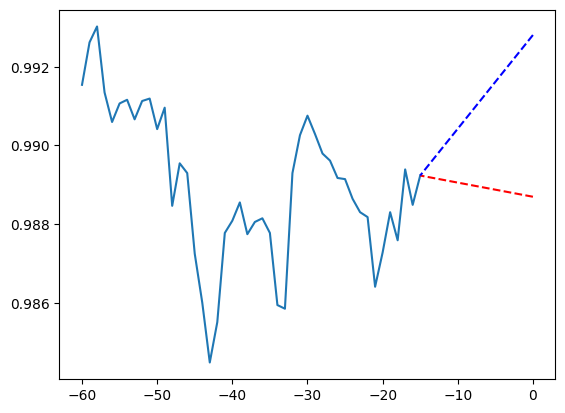

In [ ]:
# one-minute predictions and yet it can't seem to do much better than a random guess

pred_y = np.exp(model.predict(test_X) + test_X[last_col])
true_y = np.exp(test_y + test_X[last_col])
idx = randint(0, len(pred_y))

pairs = [(val, -step) for (val, step) in zip(test_X.iloc[idx], steps)]
pairs.sort(key=lambda p: p[1])

x = [t for (_, t) in pairs]
y = [math.exp(v) for (v, _) in pairs]

(last_y, last_x) = pairs[-1]

plt.figure()
plt.plot(x, y)
plt.plot([0, last_x], [pred_y.iloc[idx], math.exp(last_y)], 'r--')
plt.plot([0, last_x], [true_y.iloc[idx], math.exp(last_y)], 'b--')
plt.show()
# wow, it's Not Great(tm)